# AirGuard-LK
## Explainable AI for Compressed-Air Fault and Leak Detection

**OctWave 3.0 – Industrial AI & Intelligence**

**Primary Track:** Industrial Safety, Reliability & Resilience  
**Secondary Relevance:** Energy Efficiency & Sustainable Industry

### One-line concept

**AirGuard-LK uses explainable machine learning to detect abnormal compressed-air system behaviour with low nuisance-alarm burden so maintenance teams can inspect developing leak/fault conditions before they become larger energy and uptime problems.**

> **Scope statement:** AirGuard-LK is designed around a Sri Lankan industrial maintenance problem, but the experimental proof of concept uses the international MetroPT-3 Air Production Unit dataset. This notebook does **not** claim Sri Lankan field validation.

## Executive Summary

Compressed-air systems can continue operating while leaks or related faults waste energy, increase compressor loading, and create maintenance risk. A useful industrial monitoring system therefore needs more than high row-level classification accuracy: it must generalize to later **independent fault events**, detect faults quickly, and keep nuisance alarms low.

AirGuard-LK began as a **pre-fault early-warning** study using 15, 30, 60 and 120 minute windows. Chronological cross-event experiments showed that pre-event signatures were not sufficiently consistent across the limited documented leak episodes for a reliable universal early-warning claim.

The validated primary task was therefore reformulated as **chronological fault-state detection**. A state-aware LightGBM classifier using 71 current-minute engineering features provided the strongest development trade-off. On F02 and F03 it detected both events with a **1-minute median in-fault detection delay**, while producing approximately **0.036 false-alarm episodes/day on average** at the selected operating point.

The model configuration and threshold rule were frozen before the primary F04 evaluation. The frozen model detected F04 with **zero false-alarm episodes**, but the first persistent alert occurred **150 minutes after the documented event start**. This difficult result is retained and analysed rather than hidden.

A post-hoc model-specific eligibility sensitivity analysis increased F04 fault coverage from 173 to 269 of 270 minutes and improved PR-AUC from 0.275 to 0.553, while the detection delay and false-alarm count remained unchanged. SHAP analysis showed that pressure-related features were important across F02–F04, but the exact combination of pressure, motor-state and temperature evidence differed substantially between events.

Random Forest, XGBoost, Isolation Forest, several ensembles, a TinyCNN and a GRU were also evaluated. Increased model complexity did not improve chronological cross-event reliability enough to replace the state-aware LightGBM model.

## 1. Reproducibility Setup

The notebook loads the executed artifacts produced during development. It is intended to be run from either the repository root or the `submission/` folder.

In [30]:
from pathlib import Path
import json
import hashlib
import platform
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
CONFIG_DIR = ROOT / "configs"
SCRIPT_DIR = ROOT / "scripts"

print("Repository root:", ROOT)
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Seed:", SEED)

Repository root: d:\OctWave3\AirGuard-LK
Python: 3.14.4
NumPy: 2.5.3
Pandas: 3.0.5
Seed: 42


In [31]:
# Core paths used throughout the notebook.

RAW_PATH = ROOT / "data" / "raw" / "metropt3" / "MetroPT3(AirCompressor).csv"
EVENT_PATH = ROOT / "data" / "metadata" / "metropt3_failure_events.csv"
MASTER_PATH = ROOT / "data" / "processed" / "metropt3_model_master.parquet"
SPLIT_PATH = ROOT / "data" / "processed" / "splits" / "fault_state_split_membership.parquet"

FROZEN_CONFIG_PATH = ROOT / "configs" / "frozen_final_model.yaml"
FROZEN_MODEL_PATH = ROOT / "artifacts" / "models" / "airguard_F04_frozen_model.joblib"

paths = {
    "Raw CSV": RAW_PATH,
    "Event metadata": EVENT_PATH,
    "Model master": MASTER_PATH,
    "Fault-state split membership": SPLIT_PATH,
    "Frozen final config": FROZEN_CONFIG_PATH,
    "Frozen LightGBM model": FROZEN_MODEL_PATH,
}

path_status = pd.DataFrame([
    {
        "resource": name,
        "exists": path.exists(),
        "path": str(path.relative_to(ROOT)) if path.exists() else str(path),
        "size_MB": round(path.stat().st_size / (1024**2), 2) if path.exists() else np.nan,
    }
    for name, path in paths.items()
])

path_status

,resource,exists,path,size_MB
0,Raw CSV,True,data\raw\metropt3\MetroPT3(AirCompressor).csv,208.19
1,Event metadata,True,data\metadata\metropt3_failure_events.csv,0.00
2,Model master,True,data\processed\metropt3_model_master.parquet,205.83
3,Fault-state split membership,True,data\processed\splits\fault_state_split_member...,1.90
4,Frozen final config,True,configs\frozen_final_model.yaml,0.00
5,Frozen LightGBM model,True,artifacts\models\airguard_F04_frozen_model.joblib,0.59


### Artifact-first notebook design

Primary result tables are loaded from the saved CSV/JSON/Parquet artifacts created by the development scripts. This avoids manually retyping experimental metrics and preserves traceability.

Heavy model training is not repeated automatically inside this notebook. The exact scripts and frozen configurations remain in the repository and can be rerun when required.

## 2. Industrial Problem & Research Question

Compressed air is widely used for pneumatic actuation, packaging, process equipment, material handling, workshop tools and automated manufacturing. A compressor can continue operating while a leak or related fault increases runtime, energy use and component wear.

The intended user of AirGuard-LK is a **maintenance engineer or factory energy manager**.

### Initial research question

> Can historical compressor sensor behaviour predict documented MetroPT-3 air-leak events early enough to provide useful maintenance warning?

### Evidence-driven reformulation

Cross-event pre-fault experiments showed inconsistent generalization. The validated primary question became:

> **Can a state-aware machine-learning model trained on earlier MetroPT-3 air-leak episodes detect later documented fault states rapidly while maintaining a low nuisance-alarm rate?**

### Engineering objectives

- preserve chronology and prevent temporal leakage;
- evaluate complete later fault events instead of randomly split neighbouring rows;
- compare static, supervised, anomaly, ensemble and deep-learning alternatives;
- prioritize PR-AUC, event detection, detection delay and false alarms/day;
- explain predictions using physically interpretable sensor/state evidence;
- retain a realistic human-in-the-loop deployment path.

## 3. Existing Approaches & Research Context

Industrial predictive-maintenance systems commonly combine:

1. **Engineering alarm limits** – simple, interpretable, but prone to nuisance alarms when operating regimes vary.
2. **Supervised classifiers** – learn fault signatures from labelled examples.
3. **Anomaly detection** – model normal behaviour and flag novel deviations.
4. **Temporal feature engineering** – represent recent trends, volatility and duty cycles.
5. **Deep sequence models** – CNN/RNN/GRU/LSTM architectures that learn directly from time windows.

A major evaluation risk in industrial sensor data is **pseudo-replication**. Thousands of neighbouring samples from one long fault episode are highly correlated. Random row splitting can place observations from the same physical fault in both training and testing, producing optimistic estimates of future-event generalization.

AirGuard-LK therefore uses **chronological event-wise validation**.

## 4. Dataset Documentation — MetroPT-3

MetroPT-3 contains real multivariate time-series measurements from an **Air Production Unit (APU)** containing a compressor and pneumatic components.

After removing the exported CSV index, the raw file contains a timestamp and 15 sensor/state variables.

### Analogue variables
`TP2`, `TP3`, `H1`, `DV_pressure`, `Reservoirs`, `Oil_temperature`, `Motor_current`

### Digital / operating-state variables
`COMP`, `DV_eletric`, `Towers`, `MPG`, `LPS`, `Pressure_switch`, `Oil_level`, `Caudal_impulses`

The documented air-leak subset contains only **four independent leak episodes**. This is the central statistical limitation of the study: millions of sensor rows do not equal millions of independent failures.

In [32]:
events = pd.read_csv(
    EVENT_PATH,
    parse_dates=["start_time", "end_time"],
)

event_display = events[["event_id", "start_time", "end_time"]].copy()
event_display["duration_minutes"] = (
    (event_display["end_time"] - event_display["start_time"])
    .dt.total_seconds() / 60
)

event_display

,event_id,start_time,end_time,duration_minutes
0,F01,2020-04-18 00:00:00,2020-04-18 23:59:00,1439.0
1,F02,2020-05-29 23:30:00,2020-05-30 06:00:00,390.0
2,F03,2020-06-05 10:00:00,2020-06-07 14:30:00,3150.0
3,F04,2020-07-15 14:30:00,2020-07-15 19:00:00,270.0


In [33]:
raw_preview = pd.read_csv(RAW_PATH, nrows=8)
if "Unnamed: 0" in raw_preview.columns:
    raw_preview = raw_preview.drop(columns=["Unnamed: 0"])

print("Columns:", len(raw_preview.columns))
raw_preview

Columns: 16


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
7,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 5. Raw-Data Audit & Exploratory Analysis

The audit checks timestamp validity, missing values, duplicates, sampling cadence and acquisition gaps. Long gaps are important because rolling history must never cross an outage.

In [34]:
# Chunked raw-data audit. This reads the real CSV and may take a short time.

timestamp_parts = []
total_rows = 0
invalid_timestamps = 0
missing_total = 0

for chunk in pd.read_csv(RAW_PATH, chunksize=250_000):
    if "Unnamed: 0" in chunk.columns:
        chunk = chunk.drop(columns=["Unnamed: 0"])

    total_rows += len(chunk)

    ts = pd.to_datetime(chunk["timestamp"], errors="coerce")
    invalid_timestamps += int(ts.isna().sum())
    timestamp_parts.append(ts.dropna().to_numpy())

    missing_total += int(
        chunk.drop(columns=["timestamp"]).isna().sum().sum()
    )

timestamps = pd.Series(np.concatenate(timestamp_parts))
timestamps = pd.to_datetime(timestamps).sort_values().reset_index(drop=True)

dt = timestamps.diff().dt.total_seconds()

audit = pd.DataFrame({
    "Metric": [
        "Raw observations",
        "Invalid timestamps",
        "Duplicate timestamps",
        "Missing sensor values",
        "Median sampling interval (s)",
        "Maximum observed gap (s)",
        "Gaps > 30 s",
        "Gaps > 60 s",
        "Gaps > 300 s",
    ],
    "Value": [
        total_rows,
        invalid_timestamps,
        int(timestamps.duplicated().sum()),
        missing_total,
        float(dt.median()),
        float(dt.max()),
        int((dt > 30).sum()),
        int((dt > 60).sum()),
        int((dt > 300).sum()),
    ],
})

audit

,Metric,Value
0,Raw observations,1516948.0
1,Invalid timestamps,0.0
2,Duplicate timestamps,0.0
3,Missing sensor values,0.0
4,Median sampling interval (s),10.0
5,Maximum observed gap (s),172918.0
6,Gaps > 30 s,331.0
7,Gaps > 60 s,331.0
8,Gaps > 300 s,275.0


In [35]:
gap_summary = pd.DataFrame({
    "threshold": [">10s", ">20s", ">30s", ">60s", ">120s", ">300s", ">600s", ">3600s"],
    "gap_count": [
        int((dt > s).sum())
        for s in [10, 20, 30, 60, 120, 300, 600, 3600]
    ],
})

gap_summary

,threshold,gap_count
0,>10s,51147
1,>20s,351
2,>30s,331
3,>60s,331
4,>120s,327
5,>300s,275
6,>600s,230
7,>3600s,160


The acquisition gaps mean the time series cannot be treated as globally continuous. AirGuard-LK therefore resets temporal history across acquisition breaks and does **not** interpolate long outages.

In [36]:
master = pd.read_parquet(MASTER_PATH)
master["timestamp"] = pd.to_datetime(master["timestamp"])
master = master.sort_values("timestamp").reset_index(drop=True)

summary = pd.DataFrame({
    "Metric": [
        "One-minute rows",
        "Total columns in model master",
        "Acquisition segments",
        "Strict model-eligible rows",
    ],
    "Value": [
        len(master),
        len(master.columns),
        int(master["quality__segment_id"].nunique()),
        int(master["quality__model_feature_eligible"].sum()),
    ],
})

summary

,Metric,Value
0,One-minute rows,252720
1,Total columns in model master,288
2,Acquisition segments,332
3,Strict model-eligible rows,225696


### Operating-state relationships

EDA showed that compressor sensor behaviour depends strongly on digital operating state. The final feature set therefore includes explicit state consistency and state × analogue interactions.

In [37]:
state_relationships = pd.DataFrame({
    "Relationship": [
        "COMP ≈ MPG",
        "COMP ≠ DV_eletric",
        "Mean |TP3 - Reservoirs|",
        "95th percentile |TP3 - Reservoirs|",
    ],
    "Value": [
        float((master["COMP_mean"].round() == master["MPG_mean"].round()).mean()),
        float((master["COMP_mean"].round() != master["DV_eletric_mean"].round()).mean()),
        float(master["TP3_Reservoir_abs_diff_mean"].mean()),
        float(master["TP3_Reservoir_abs_diff_mean"].quantile(0.95)),
    ],
})

state_relationships

,Relationship,Value
0,COMP ≈ MPG,0.993610
1,COMP ≠ DV_eletric,0.980279
2,Mean |TP3 - Reservoirs|,0.001855
3,95th percentile |TP3 - Reservoirs|,0.004333


## 6. Causal Preprocessing & Feature Engineering

Raw observations were aggregated to **one-minute availability rows**.

### Causal timestamp convention

Measurements observed from `14:29:00` to `14:29:59` become available in the feature row timestamped `14:30`.

Therefore \(X_t\) contains information available at or before \(t\), never future observations.

### Gap-safe segmentation

A new acquisition segment is created when the incoming raw gap exceeds the allowed continuity threshold. Rolling features are never allowed to cross segment boundaries.

### Feature families

The broader development table contains current features plus rolling trends, volatility, duty-cycle and transition features over multiple windows. The final selected model uses only **71 current-minute/state-aware features**, because these transferred more reliably between independent fault episodes.

In [38]:
import joblib

frozen_bundle = joblib.load(FROZEN_MODEL_PATH)

selected_features = list(frozen_bundle["features"])
frozen_threshold = float(frozen_bundle["threshold_value"])
frozen_persistence = int(frozen_bundle["persistence_minutes"])

print("Selected features:", len(selected_features))
print("Frozen threshold:", frozen_threshold)
print("Persistence:", frozen_persistence, "minutes")

pd.DataFrame({"feature": selected_features}).head(25)

Selected features: 71
Frozen threshold: 0.6071059893996522
Persistence: 3 minutes


,feature
0,TP2_mean
1,TP2_std
2,TP2_min
3,TP2_max
4,TP2_last
5,TP3_mean
6,TP3_std
7,TP3_min
8,TP3_max
9,TP3_last


In [39]:
quality_columns = [c for c in master.columns if c.startswith("quality__")]
target_columns = [c for c in master.columns if c.startswith("target__")]

model_feature_columns = [
    c for c in master.columns
    if c not in ["timestamp", *quality_columns, *target_columns]
]

processed_summary = pd.DataFrame({
    "Metric": [
        "Model features available during development",
        "Quality metadata columns",
        "Target metadata columns",
        "Selected final current/state-aware features",
    ],
    "Value": [
        len(model_feature_columns),
        len(quality_columns),
        len(target_columns),
        len(selected_features),
    ],
})

processed_summary

,Metric,Value
0,Model features available during development,264
1,Quality metadata columns,8
2,Target metadata columns,15
3,Selected final current/state-aware features,71


## 7. Leakage-Safe Chronological Validation

Random row splitting was rejected because neighbouring minutes from the same physical fault are strongly correlated.

### Development

- **Fold 1:** train on F01 history → evaluate F02
- **Fold 2:** train on F01 + F02 history → evaluate F03

### Final frozen chronological model-selection holdout

- train final model on F01 + F02 + F03
- evaluate F04

F04 was visible during dataset-level exploratory analysis, so this notebook deliberately describes it as a **chronological model-selection holdout**, not as a sample that was never viewed in any form.

The final feature set, hyperparameters, threshold quantile and 3-minute persistence rule were frozen before the primary F04 evaluation.

In [40]:
split_membership = pd.read_parquet(SPLIT_PATH)
split_membership["timestamp"] = pd.to_datetime(split_membership["timestamp"])

split_counts = (
    split_membership
    .groupby(["split", "role"])
    .size()
    .rename("rows")
    .reset_index()
)

split_counts.pivot(
    index="split",
    columns="role",
    values="rows",
).fillna(0).astype(int)

role,evaluation_failure,evaluation_negative,evaluation_pre_event_context,train_failure,train_ineligible,train_negative,train_pre_event_context,train_recovery
split,,,,,,,,
fault_F02,391,39761,360,1316,9329,83636,360,334
fault_F03,2624,6341,360,1707,14130,123396,720,677


### Ambiguous windows

For fault-state development, the **360 minutes before each documented event** are excluded from normal examples, and post-event recovery intervals are also excluded. This avoids labelling potentially transitional behaviour as confidently normal.

## 8. Initial Pre-Fault Early-Warning Experiments

The original AirGuard-LK hypothesis focused on prediction before the documented leak start. Candidate windows of 15, 30, 60 and 120 minutes were tested with linear, tree-based and anomaly models.

The central negative result was **cross-event inconsistency**:

- F03 contained useful pre-event information for several models, particularly close to onset.
- F02 often remained near prevalence under the same models.
- no universal pre-leak signature transferred reliably enough to support a strong early-warning claim.

This negative result motivated the evidence-driven transition to fault-state detection rather than forcing the original hypothesis.

In [41]:
# Load available pre-fault development artifacts if present.
candidate_files = [
    ROOT / "artifacts" / "tables" / "development_baseline_macro.csv",
    ROOT / "artifacts" / "tables" / "nonlinear_development_macro.csv",
    ROOT / "artifacts" / "metrics" / "development_baselines.csv",
]

for p in candidate_files:
    if p.exists():
        print("\nLoaded:", p.relative_to(ROOT))
        display(pd.read_csv(p).head(30))

If the project artifact filenames differ, the executed development scripts remain the authoritative source. The competition claim is qualitative here: **pre-event prediction was investigated and rejected as insufficiently stable across independent events.**

## 9. Fault-State Reformulation

The primary validated task treats the documented air-leak interval as the positive fault state.

Operationally, the objective is:

> **Recognize a documented abnormal compressor state as rapidly as possible while minimizing nuisance alarms during normal operation.**

The evaluation therefore combines:

- **PR-AUC / Average Precision** for rare-event ranking;
- **event detection rate**;
- **detection delay** from the documented event start;
- **false-alarm episodes/day**;
- a **3-minute persistence rule** so a single isolated high score does not become a maintenance alert.

## 10. Baselines & Model Family Comparison

AirGuard-LK deliberately evaluates model families of increasing complexity:

- Static engineering threshold baseline
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- Isolation Forest
- Ensemble combinations
- TinyCNN-30m
- GRU-30m

The purpose is not to maximize algorithmic complexity. The selected model must provide the strongest **cross-event industrial operating point**.

In [42]:
# Main fault-state benchmark artifacts.
benchmark_candidates = [
    ROOT / "artifacts" / "tables" / "fault_state_macro_ranking.csv",
    ROOT / "artifacts" / "metrics" / "fault_state_ranking.csv",
    ROOT / "artifacts" / "tables" / "fault_state_ranking_scoreboard.csv",
]

for p in benchmark_candidates:
    if p.exists():
        print("\nLoaded:", p.relative_to(ROOT))
        display(pd.read_csv(p))


Loaded: artifacts\tables\fault_state_ranking_scoreboard.csv


,model,mean_pr_auc,minimum_event_pr_auc,maximum_event_pr_auc,mean_average_precision,mean_roc_auc,mean_ap_lift
0,Isolation Forest Temporal,0.423191,0.032759,0.813622,0.423361,0.917447,3.077156
1,LightGBM Current,0.920766,0.855593,0.985940,0.882830,0.993797,41.715134
2,LightGBM Temporal,0.783256,0.577578,0.988935,0.714209,0.990189,24.238757
3,Static Normal-Range,0.455827,0.047917,0.863738,0.436754,0.910885,4.817065


The development fault-state benchmark established **LightGBM Current** as the leading model. The previously executed development result was:

- Mean PR-AUC: **0.920766**
- Minimum-event PR-AUC: **0.855593**
- Development events detected: **2 / 2**
- Median in-fault delay: **1 minute**
- Mean false-alarm episodes/day at the selected operating point: **0.036216**
- Worst-fold false-alarm episodes/day: **0.072433**

These values are retained here as the verified development benchmark and are compared against the saved challenger artifacts below.

## 11. Selected Model — State-Aware LightGBM

The selected classifier uses 71 current-minute/state-aware features.

### Frozen configuration

| Parameter | Value |
|---|---:|
| Objective | binary |
| Trees | 350 |
| Learning rate | 0.03 |
| Num leaves | 15 |
| Max depth | 5 |
| Min child samples | 20 |
| Subsample | 0.8 |
| Column sample | 0.8 |
| L2 regularization | 1.0 |
| Class weighting | balanced |
| Random seed | 42 |

### Alarm rule

The numerical alarm threshold is derived from the **99.95th percentile of final-training normal scores**. A maintenance alert requires **3 consecutive minutes** above threshold.

The threshold is therefore tied to normal-behaviour rarity rather than an arbitrary probability such as 0.5.

In [43]:
import yaml

if FROZEN_CONFIG_PATH.exists():
    with open(FROZEN_CONFIG_PATH, "r", encoding="utf-8") as f:
        frozen_cfg = yaml.safe_load(f)
    display(pd.json_normalize(frozen_cfg, sep=".").T.rename(columns={0: "value"}).head(80))

    config_sha = hashlib.sha256(FROZEN_CONFIG_PATH.read_bytes()).hexdigest()
    print("Frozen config SHA256:", config_sha)
else:
    print("Frozen config file not found:", FROZEN_CONFIG_PATH)

,value
project,AirGuard-LK
random_seed,42
task.name,chronological_fault_state_detection
model.name,LightGBM Current
model.feature_set,current_state_aware
model.parameters.objective,binary
model.parameters.n_estimators,350
model.parameters.learning_rate,0.03
model.parameters.num_leaves,15
model.parameters.max_depth,5


Frozen config SHA256: 17d0d435e34e677f55269cb797e6312edefcb2c53a0635a331f2e7558699f265


In [44]:
# Gain-based feature importance from the frozen final model.
fi_path = ROOT / "artifacts" / "tables" / "final_F04_feature_importance.csv"

if fi_path.exists():
    final_gain_importance = pd.read_csv(fi_path)
    display(final_gain_importance.head(15))
else:
    print("Missing:", fi_path)

,feature,gain,split
0,DV_pressure_mean,2.268249e+06,291
1,DV_pressure_max,6.016694e+05,582
2,DV_pressure_min,7.466781e+04,223
3,Oil_temperature_mean,4.999415e+04,257
4,Oil_temperature_min,3.790054e+04,385
5,TP2_max,2.269963e+04,264
6,TP2_x_COMP0,1.875515e+04,194
7,H1_minus_TP3_mean,7.140866e+03,227
8,Oil_temperature_max,5.398209e+03,273
9,Motor_current_x_COMP1,4.827802e+03,124


## 12. Development Results — F02 and F03

In [45]:
development_results = pd.DataFrame([
    {
        "event": "F02",
        "PR_AUC": 0.855593,
        "detected": "Yes",
        "detection_delay_min": 1,
    },
    {
        "event": "F03",
        "PR_AUC": 0.985940,
        "detected": "Yes",
        "detection_delay_min": 1,
    },
])

development_results

,event,PR_AUC,detected,detection_delay_min
0,F02,0.855593,Yes,1
1,F03,0.985940,Yes,1


In [46]:
development_summary = pd.DataFrame({
    "metric": [
        "Mean PR-AUC",
        "Minimum-event PR-AUC",
        "Events detected",
        "Median in-fault detection delay",
        "Mean false-alarm episodes/day",
        "Worst-fold false-alarm episodes/day",
    ],
    "result": [
        0.920766,
        0.855593,
        "2 / 2",
        "1 min",
        0.036216,
        0.072433,
    ],
})

development_summary

,metric,result
0,Mean PR-AUC,0.920766
1,Minimum-event PR-AUC,0.855593
2,Events detected,2 / 2
3,Median in-fault detection delay,1 min
4,Mean false-alarm episodes/day,0.036216
5,Worst-fold false-alarm episodes/day,0.072433


### Why PR-AUC rather than accuracy?

Fault minutes are rare relative to normal operation. Accuracy can therefore look excellent even for a model that is operationally useless. PR-AUC and Average Precision focus on the model's ability to rank rare positives without flooding maintenance teams with false positives.

## 13. Frozen F04 Chronological Holdout

The final model was trained on F01–F03. The final numerical threshold was derived only from final-training normal scores.

No feature, model, hyperparameter or threshold change was made in response to the primary F04 result.

In [47]:
f04_result_path = ROOT / "artifacts" / "metrics" / "final_F04_holdout_result.json"

with open(f04_result_path, "r", encoding="utf-8") as f:
    f04_primary = json.load(f)

pd.Series(f04_primary, name="value").to_frame()

,value
holdout_event,F04
training_events,"[F01, F02, F03]"
frozen_config_sha256,17d0d435e34e677f55269cb797e6312edefcb2c53a0635...
model,LightGBM Current
feature_count,71
threshold_quantile,0.9995
threshold_value,0.607106
persistence_minutes,3
holdout_normal_minutes,39155
holdout_failure_minutes,173


### Primary holdout interpretation

The frozen model **detected F04**, but only after **150 minutes**. At the same time, it produced **zero false-alarm episodes** across the strict holdout-normal evaluation interval.

This result is deliberately retained. It demonstrates that F04 is materially different from F02/F03 and prevents an overconfident claim that every leak can be recognized immediately.

In [48]:
# Compact primary holdout table
keys = [
    "pr_auc",
    "average_precision",
    "roc_auc",
    "ap_lift_over_prevalence",
    "event_detected",
    "detection_delay_minutes",
    "false_alarm_episodes",
    "false_alarm_episodes_per_day",
]

pd.DataFrame({
    "metric": keys,
    "F04_primary": [f04_primary[k] for k in keys],
})

,metric,F04_primary
0,pr_auc,0.275400
1,average_precision,0.276220
2,roc_auc,0.951232
3,ap_lift_over_prevalence,62.792900
4,event_detected,1.000000
5,detection_delay_minutes,150.000000
6,false_alarm_episodes,0.000000
7,false_alarm_episodes_per_day,0.000000


## 14. F04 Error Analysis & Eligibility Sensitivity

The strict shared development eligibility mask required 120 minutes of uninterrupted history because the broader temporal feature pipeline used long rolling windows.

The final selected LightGBM, however, uses only current-minute features.

During F04, a new acquisition segment began partway through the fault. This caused 97 later fault minutes to fail the strict 120-minute-history requirement even though valid current-minute features were present.

This did **not** cause the 150-minute detection delay: the persistent alert occurred before the acquisition break.

In [49]:
sens_path = ROOT / "artifacts" / "metrics" / "final_F04_current_eligibility_sensitivity.json"

with open(sens_path, "r", encoding="utf-8") as f:
    f04_sensitivity = json.load(f)

comparison = pd.DataFrame([
    {
        "evaluation": "Frozen primary",
        "fault_minutes": f04_primary["holdout_failure_minutes"],
        "PR_AUC": f04_primary["pr_auc"],
        "Average_Precision": f04_primary["average_precision"],
        "ROC_AUC": f04_primary["roc_auc"],
        "detection_delay_min": f04_primary["detection_delay_minutes"],
        "false_alarm_episodes": f04_primary["false_alarm_episodes"],
    },
    {
        "evaluation": "Post-hoc current-feature eligibility",
        "fault_minutes": f04_sensitivity["holdout_failure_minutes"],
        "PR_AUC": f04_sensitivity["pr_auc"],
        "Average_Precision": f04_sensitivity["average_precision"],
        "ROC_AUC": f04_sensitivity["roc_auc"],
        "detection_delay_min": f04_sensitivity["detection_delay_minutes"],
        "false_alarm_episodes": f04_sensitivity["false_alarm_episodes"],
    },
])

comparison

,evaluation,fault_minutes,PR_AUC,Average_Precision,ROC_AUC,detection_delay_min,false_alarm_episodes
0,Frozen primary,173,0.275400,0.276220,0.951232,150.0,0
1,Post-hoc current-feature eligibility,269,0.553451,0.553757,0.970337,150.0,0


The sensitivity analysis is explicitly **post-hoc**. It does not replace the primary frozen holdout. No retraining or threshold change occurred.

Its purpose is to show that model-specific eligibility increases evaluation coverage while leaving the operational conclusion unchanged.

In [50]:
temporal_error_path = ROOT / "artifacts" / "tables" / "final_F04_temporal_error_analysis.csv"

if temporal_error_path.exists():
    f04_temporal = pd.read_csv(temporal_error_path)
    display(f04_temporal)

,time_bin,observed_minutes,median_score,mean_score,p90_score,max_score,minutes_above_threshold,fraction_above_threshold,frozen_threshold
0,0-5,5,0.000994,0.001144,0.001579,0.001911,0,0.000000,0.607106
1,5-15,10,0.001100,0.002207,0.002419,0.012929,0,0.000000,0.607106
2,15-30,15,0.001305,0.006990,0.015211,0.015710,0,0.000000,0.607106
3,30-60,30,0.001054,0.001113,0.001502,0.001546,0,0.000000,0.607106
4,60-90,30,0.000958,0.000932,0.001463,0.001762,0,0.000000,0.607106
5,90-120,30,0.007707,0.020798,0.046147,0.182500,0,0.000000,0.607106
6,120-150,30,0.039502,0.200279,0.586833,0.761096,3,0.100000,0.607106
7,150-180,23,0.600075,0.682122,0.883188,0.894263,11,0.478261,0.607106


### F04 risk trajectory

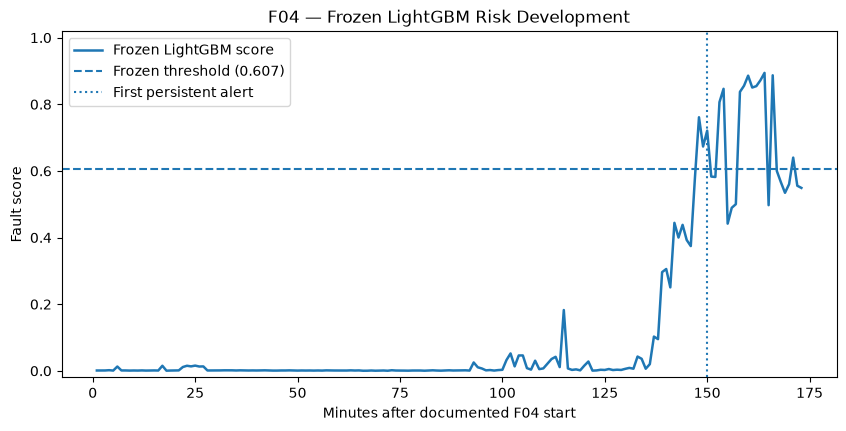

In [51]:
pred_path = ROOT / "artifacts" / "metrics" / "final_F04_predictions.parquet"

if pred_path.exists():
    f04_pred = pd.read_parquet(pred_path)
    f04_pred["timestamp"] = pd.to_datetime(f04_pred["timestamp"])

    fault_pred = f04_pred[f04_pred["role"] == "holdout_failure"].copy()
    start = pd.Timestamp("2020-07-15 14:30:00")
    fault_pred["minutes_after_start"] = (
        (fault_pred["timestamp"] - start).dt.total_seconds() / 60
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(
        fault_pred["minutes_after_start"],
        fault_pred["score"],
        linewidth=1.8,
        label="Frozen LightGBM score",
    )
    ax.axhline(
        f04_primary["threshold_value"],
        linestyle="--",
        label=f"Frozen threshold ({f04_primary['threshold_value']:.3f})",
    )
    ax.axvline(
        f04_primary["detection_delay_minutes"],
        linestyle=":",
        label="First persistent alert",
    )
    ax.set_xlabel("Minutes after documented F04 start")
    ax.set_ylabel("Fault score")
    ax.set_title("F04 — Frozen LightGBM Risk Development")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    plt.show()
else:
    print("Missing:", pred_path)

The key error-analysis result is that F04 was **not** sitting just below the alarm threshold during its early phase. Scores remained around 0.001 through much of the first 90 minutes, began increasing after roughly 120 minutes, and crossed the frozen threshold only near 148 minutes.

Therefore, a small post-hoc threshold adjustment would not have solved the early-detection problem.

## 15. Explainability with SHAP

TreeSHAP was applied **after model selection**.

SHAP values explain how features contribute to the LightGBM prediction. They are **not evidence of physical causation**.

In [52]:
shap_event_path = ROOT / "artifacts" / "tables" / "shap_event_feature_importance.csv"

shap_event = pd.read_csv(shap_event_path)

for event in ["F02", "F03", "F04"]:
    print("\n", event)
    display(
        shap_event[shap_event["event"] == event]
        .sort_values("mean_abs_shap", ascending=False)
        .head(12)
        [["feature", "mean_abs_shap", "mean_signed_shap", "mean_feature_value"]]
    )


 F02


,feature,mean_abs_shap,mean_signed_shap,mean_feature_value
15,DV_pressure_mean,11.575674,11.568454,1.919290
18,DV_pressure_max,3.203054,3.200555,2.034399
11,H1_std,1.835437,1.831448,0.012074
17,DV_pressure_min,0.979145,0.975284,1.511130
19,DV_pressure_last,0.457243,0.457157,1.917074
27,Oil_temperature_min,0.316288,0.316218,75.731010
68,Motor_current_x_COMP1,0.296690,0.295811,0.041476
33,Motor_current_max,0.249070,0.248793,5.702001
5,TP3_mean,0.233989,0.233361,8.405335
3,TP2_max,0.148451,0.148308,8.525192



 F03


,feature,mean_abs_shap,mean_signed_shap,mean_feature_value
86,DV_pressure_mean,3.184365,3.184365,2.032114
74,TP2_max,1.302561,-1.070485,8.268469
89,DV_pressure_max,1.146490,-0.401067,2.148400
88,DV_pressure_min,0.952888,0.952888,1.613564
98,Oil_temperature_min,0.878519,0.878519,75.579125
79,TP3_max,0.654675,0.011498,8.066408
139,Motor_current_x_COMP1,0.517982,0.517982,0.000000
82,H1_std,0.410359,0.410311,0.000972
136,H1_minus_TP3_mean,0.315704,-0.160181,-8.056401
75,TP2_last,0.308840,0.308840,7.922708



 F04


,feature,mean_abs_shap,mean_signed_shap,mean_feature_value
159,DV_pressure_min,1.449386,1.449386,-0.009799
210,Motor_current_x_COMP1,1.442669,1.427922,0.093998
169,Oil_temperature_min,1.313957,1.313957,83.683643
153,H1_std,0.627382,0.626475,0.003083
160,DV_pressure_max,0.530164,-0.530164,-0.007643
157,DV_pressure_mean,0.485501,0.398276,-0.008761
167,Oil_temperature_mean,0.282678,0.282678,83.871674
161,DV_pressure_last,0.281486,0.276460,-0.008810
205,TP3_minus_Reservoirs_mean,0.269736,-0.224211,0.002216
170,Oil_temperature_max,0.240908,0.240908,84.051022


### Event-level interpretation

**F02** was dominated by a very strong `DV_pressure_mean` contribution, explaining its rapid recognition.

**F03** also contained strong pressure evidence, but importance was distributed across pressure, `TP2`, oil temperature and state/current variables.

**F04** presented a different regime. Its strongest contributors included `DV_pressure_min`, `Motor_current_x_COMP1`, `Oil_temperature_min`, `H1_std` and additional pressure statistics.

The recurring importance of pressure-related features across F02–F04 supports an engineering interpretation that **pressure behaviour is consistently informative**, while the exact manifestation differs between events.

In [53]:
checkpoint_path = ROOT / "artifacts" / "tables" / "f04_shap_checkpoints.csv"
f04_cp = pd.read_csv(checkpoint_path)
f04_cp["timestamp"] = pd.to_datetime(f04_cp["timestamp"])

selected_cp_features = [
    "Motor_current_x_COMP1",
    "DV_pressure_mean",
    "Oil_temperature_mean",
]

display(
    f04_cp[f04_cp["feature"].isin(selected_cp_features)]
    [["actual_offset_minutes", "score", "feature", "feature_value", "shap_value"]]
)

,actual_offset_minutes,score,feature,feature_value,shap_value
1,5.0,0.000757,Motor_current_x_COMP1,0.000000,1.029722
5,5.0,0.000757,DV_pressure_mean,-0.008667,-0.079414
6,5.0,0.000757,Oil_temperature_mean,83.683333,0.133100
11,30.0,0.001054,Motor_current_x_COMP1,0.000000,1.040306
15,30.0,0.001054,DV_pressure_mean,-0.008667,-0.077283
16,30.0,0.001054,Oil_temperature_mean,87.458333,0.153962
21,60.0,0.001006,Motor_current_x_COMP1,0.000000,1.066774
25,60.0,0.001006,DV_pressure_mean,-0.008000,-0.075188
26,60.0,0.001006,Oil_temperature_mean,87.566667,0.133527
31,90.0,0.001345,Motor_current_x_COMP1,0.000000,1.075666


### What changed before F04 detection?

Around +140 to +150 minutes, several independent pieces of evidence became fault-supportive at the same time:

- the motor-current/state interaction became more strongly positive;
- `DV_pressure_mean` changed from a negative SHAP contribution to a positive one;
- oil-temperature contribution increased.

This multi-feature alignment explains the sharp rise in model risk around the eventual persistent alert.

shap_event_comparison.png


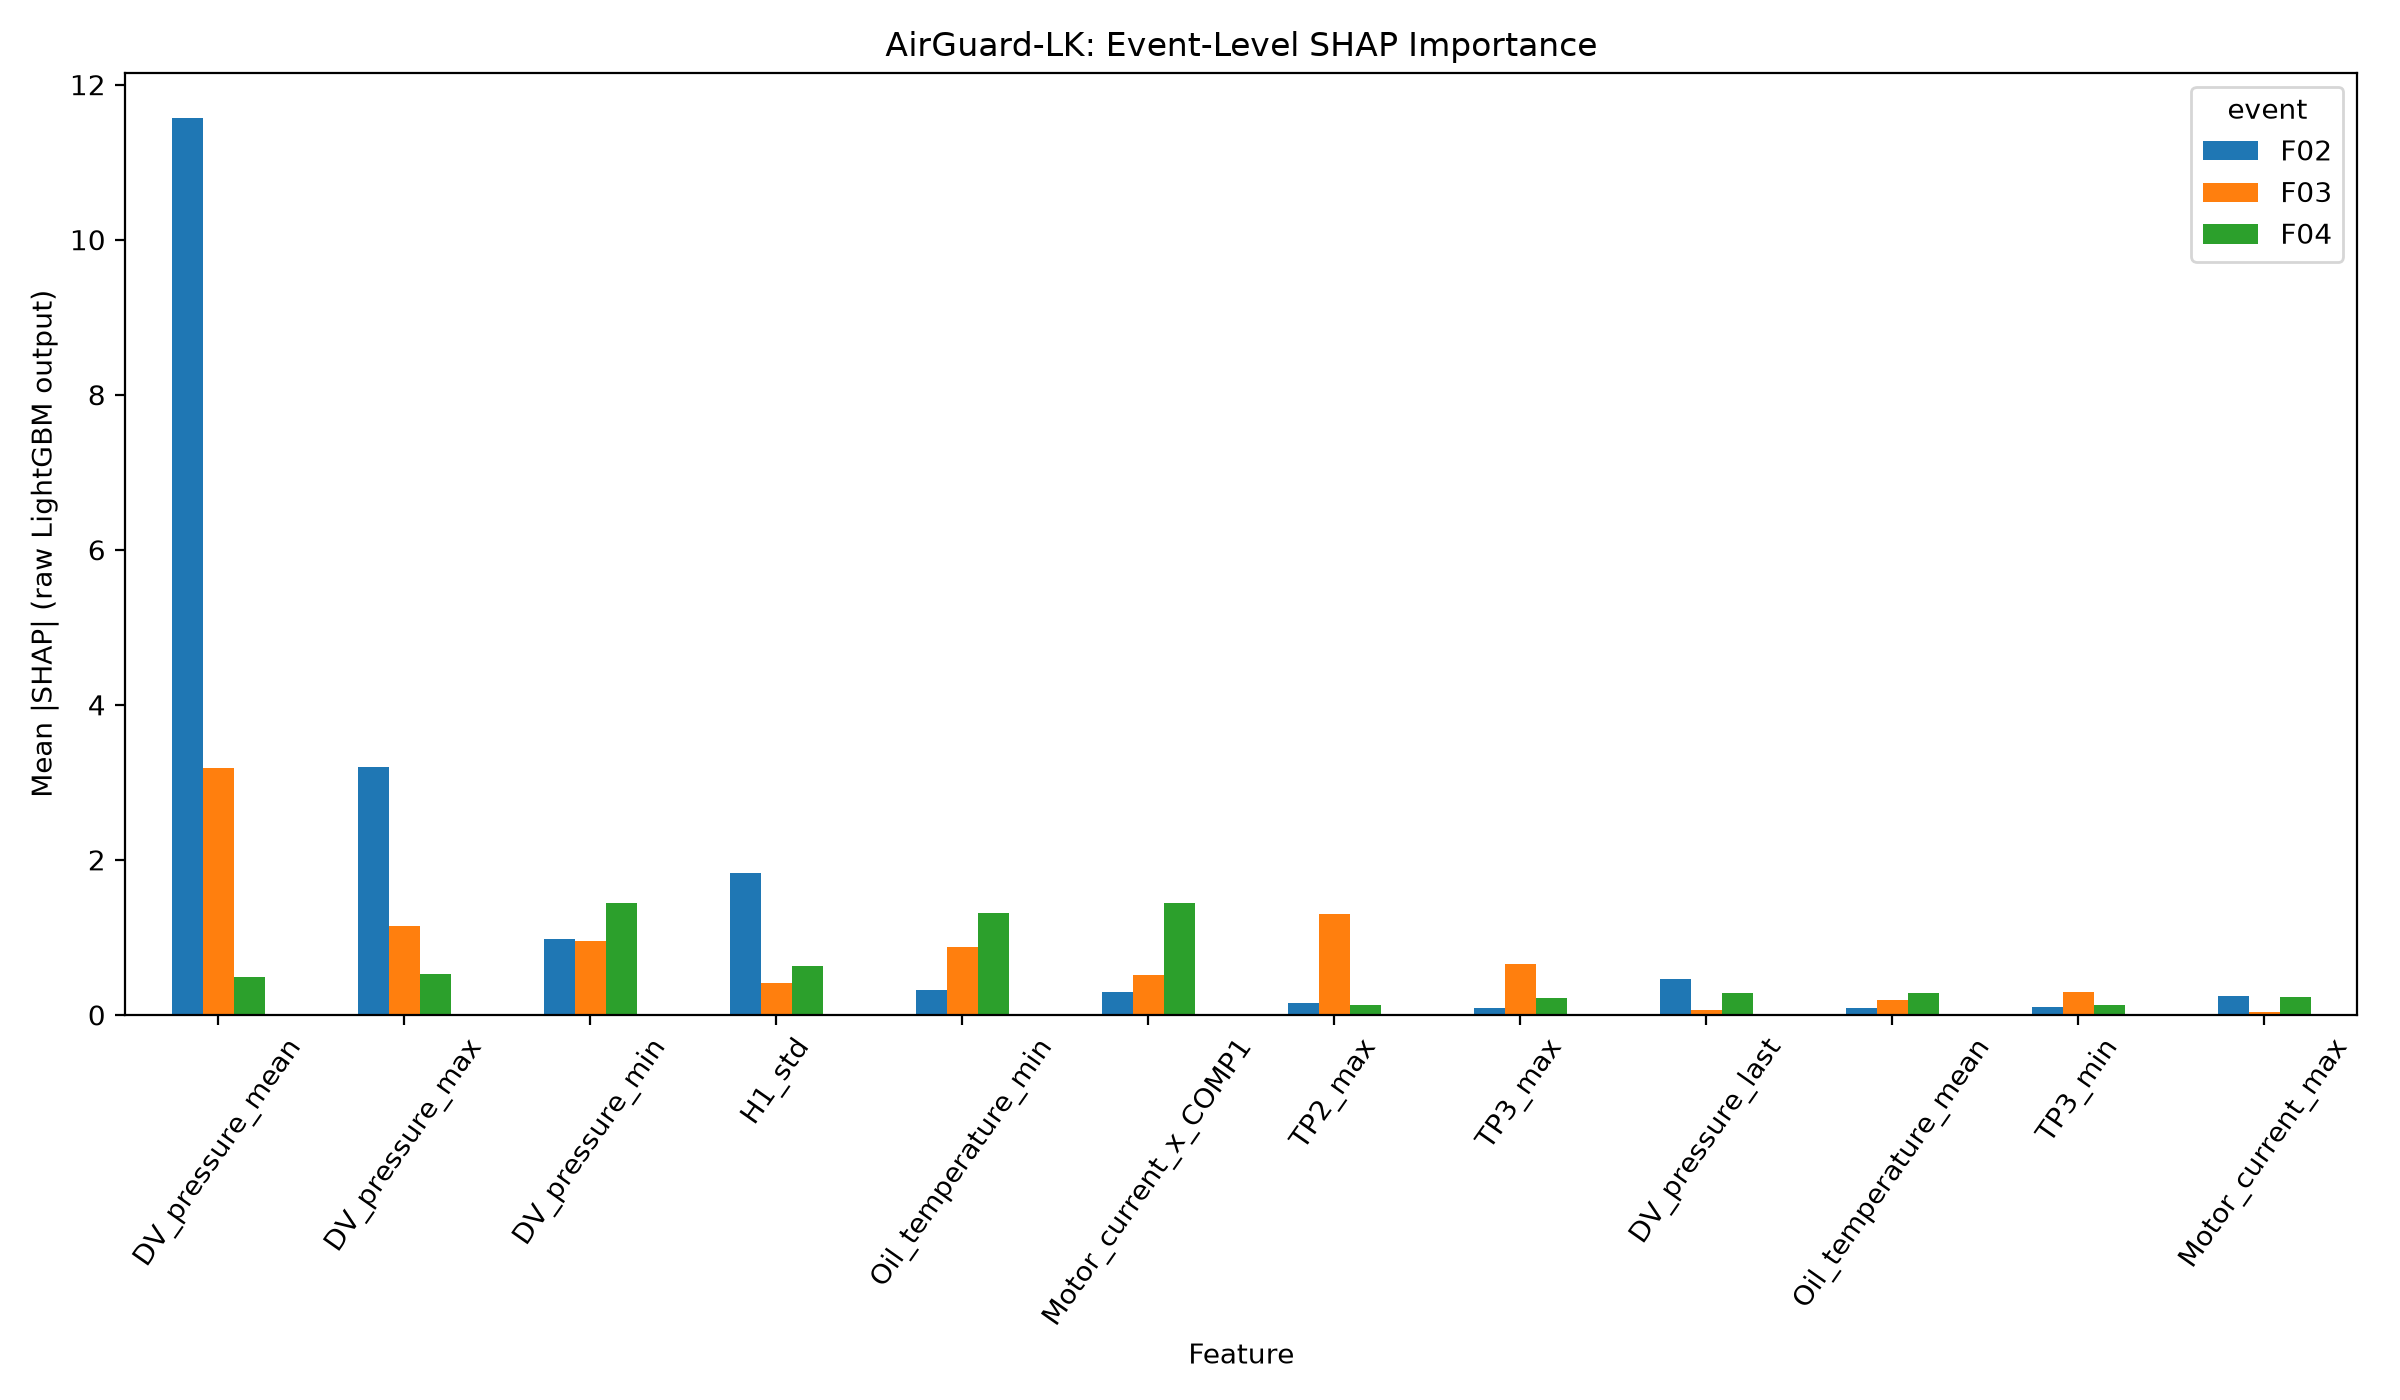

f04_risk_timeline.png


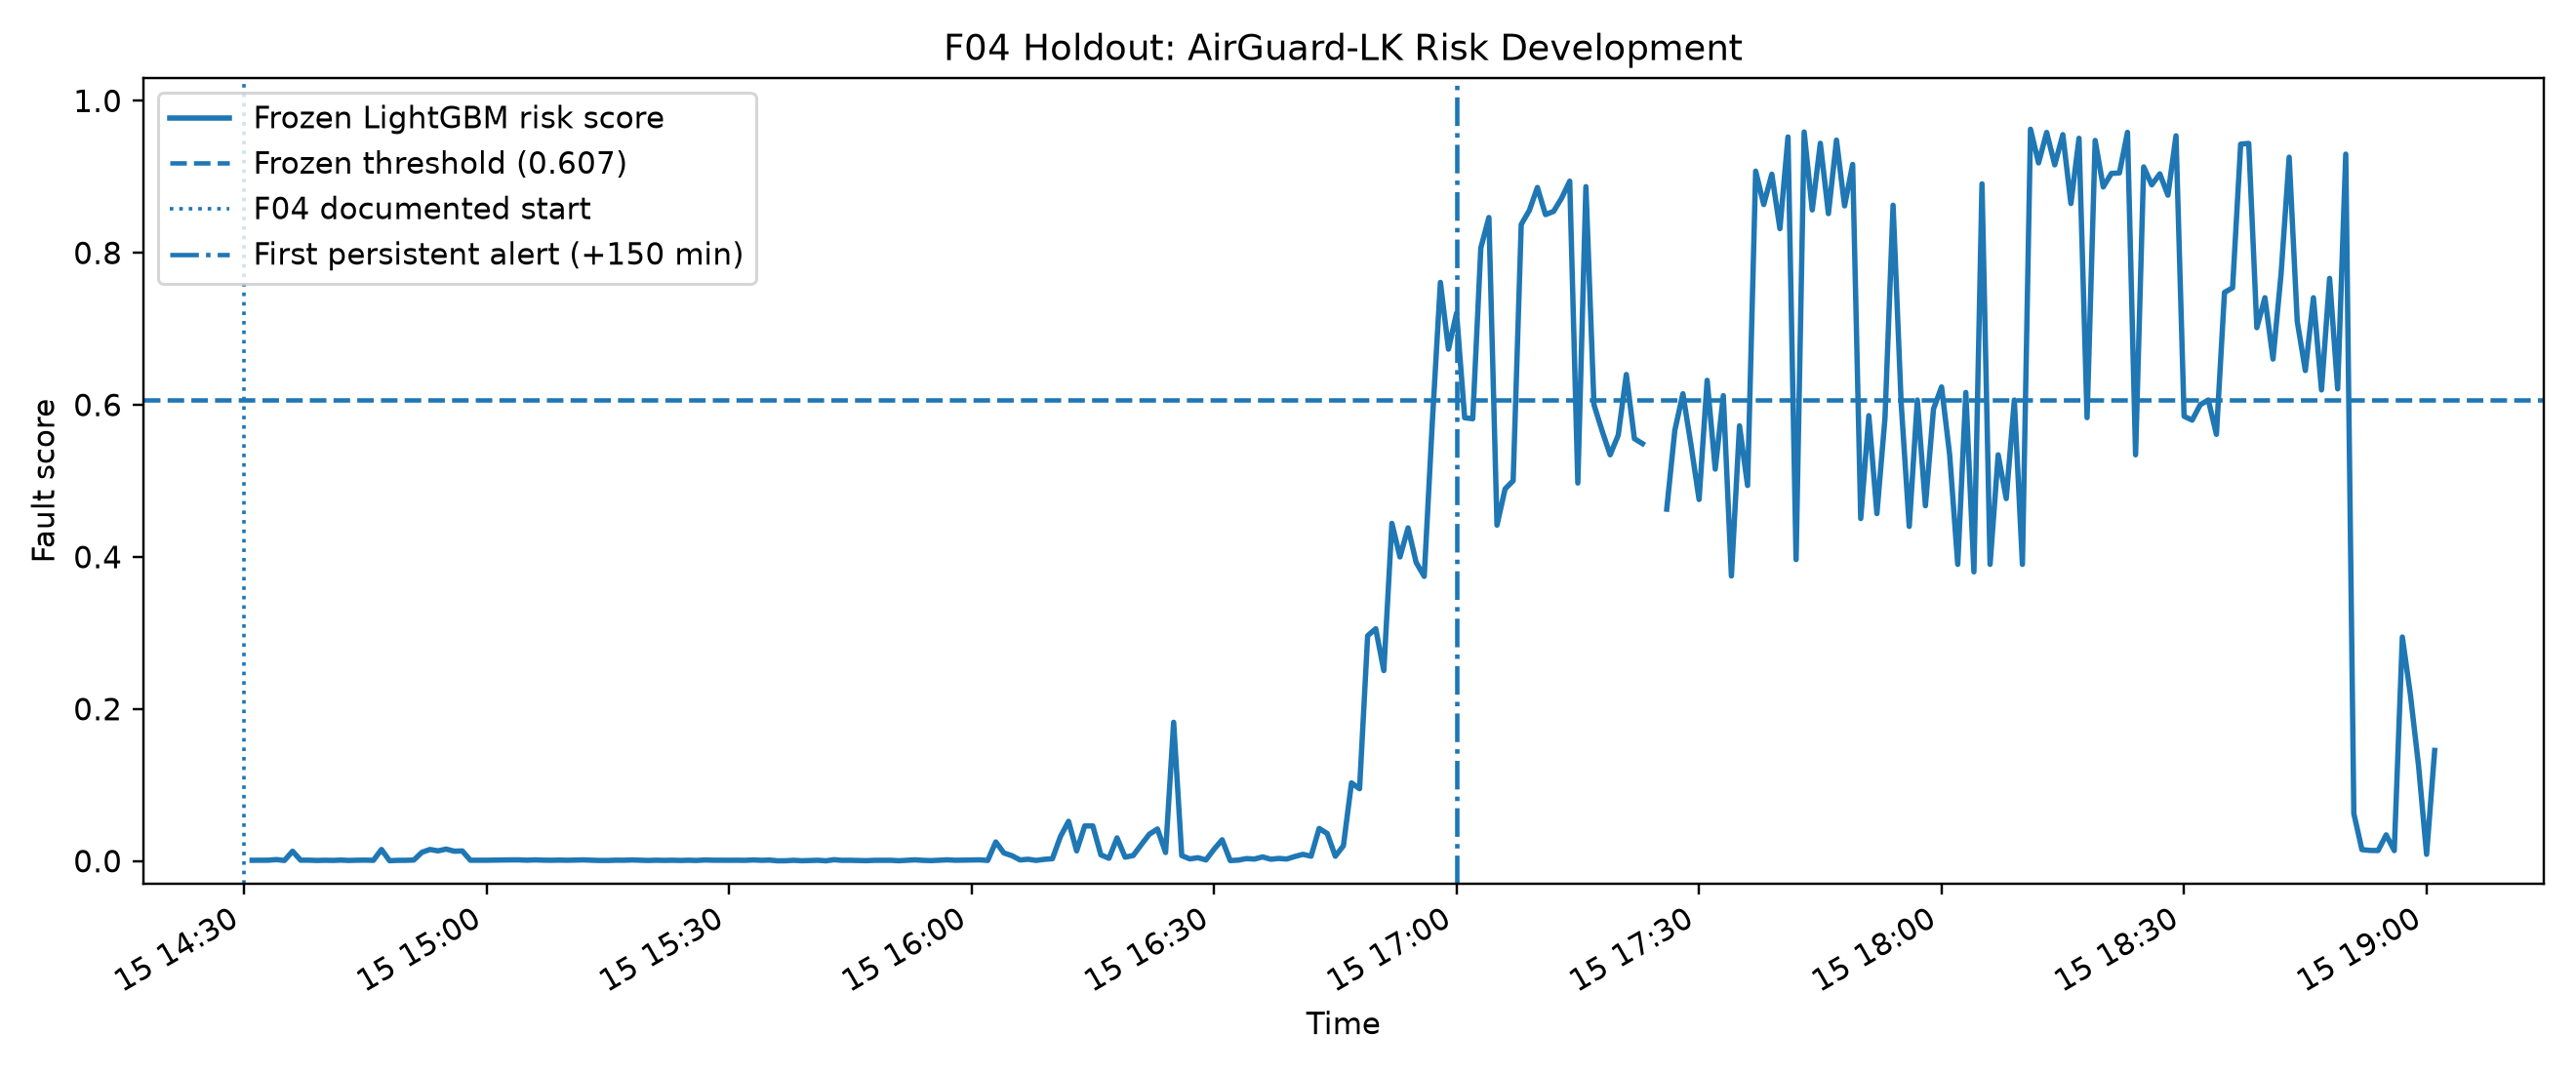

f04_shap_checkpoint_heatmap.png


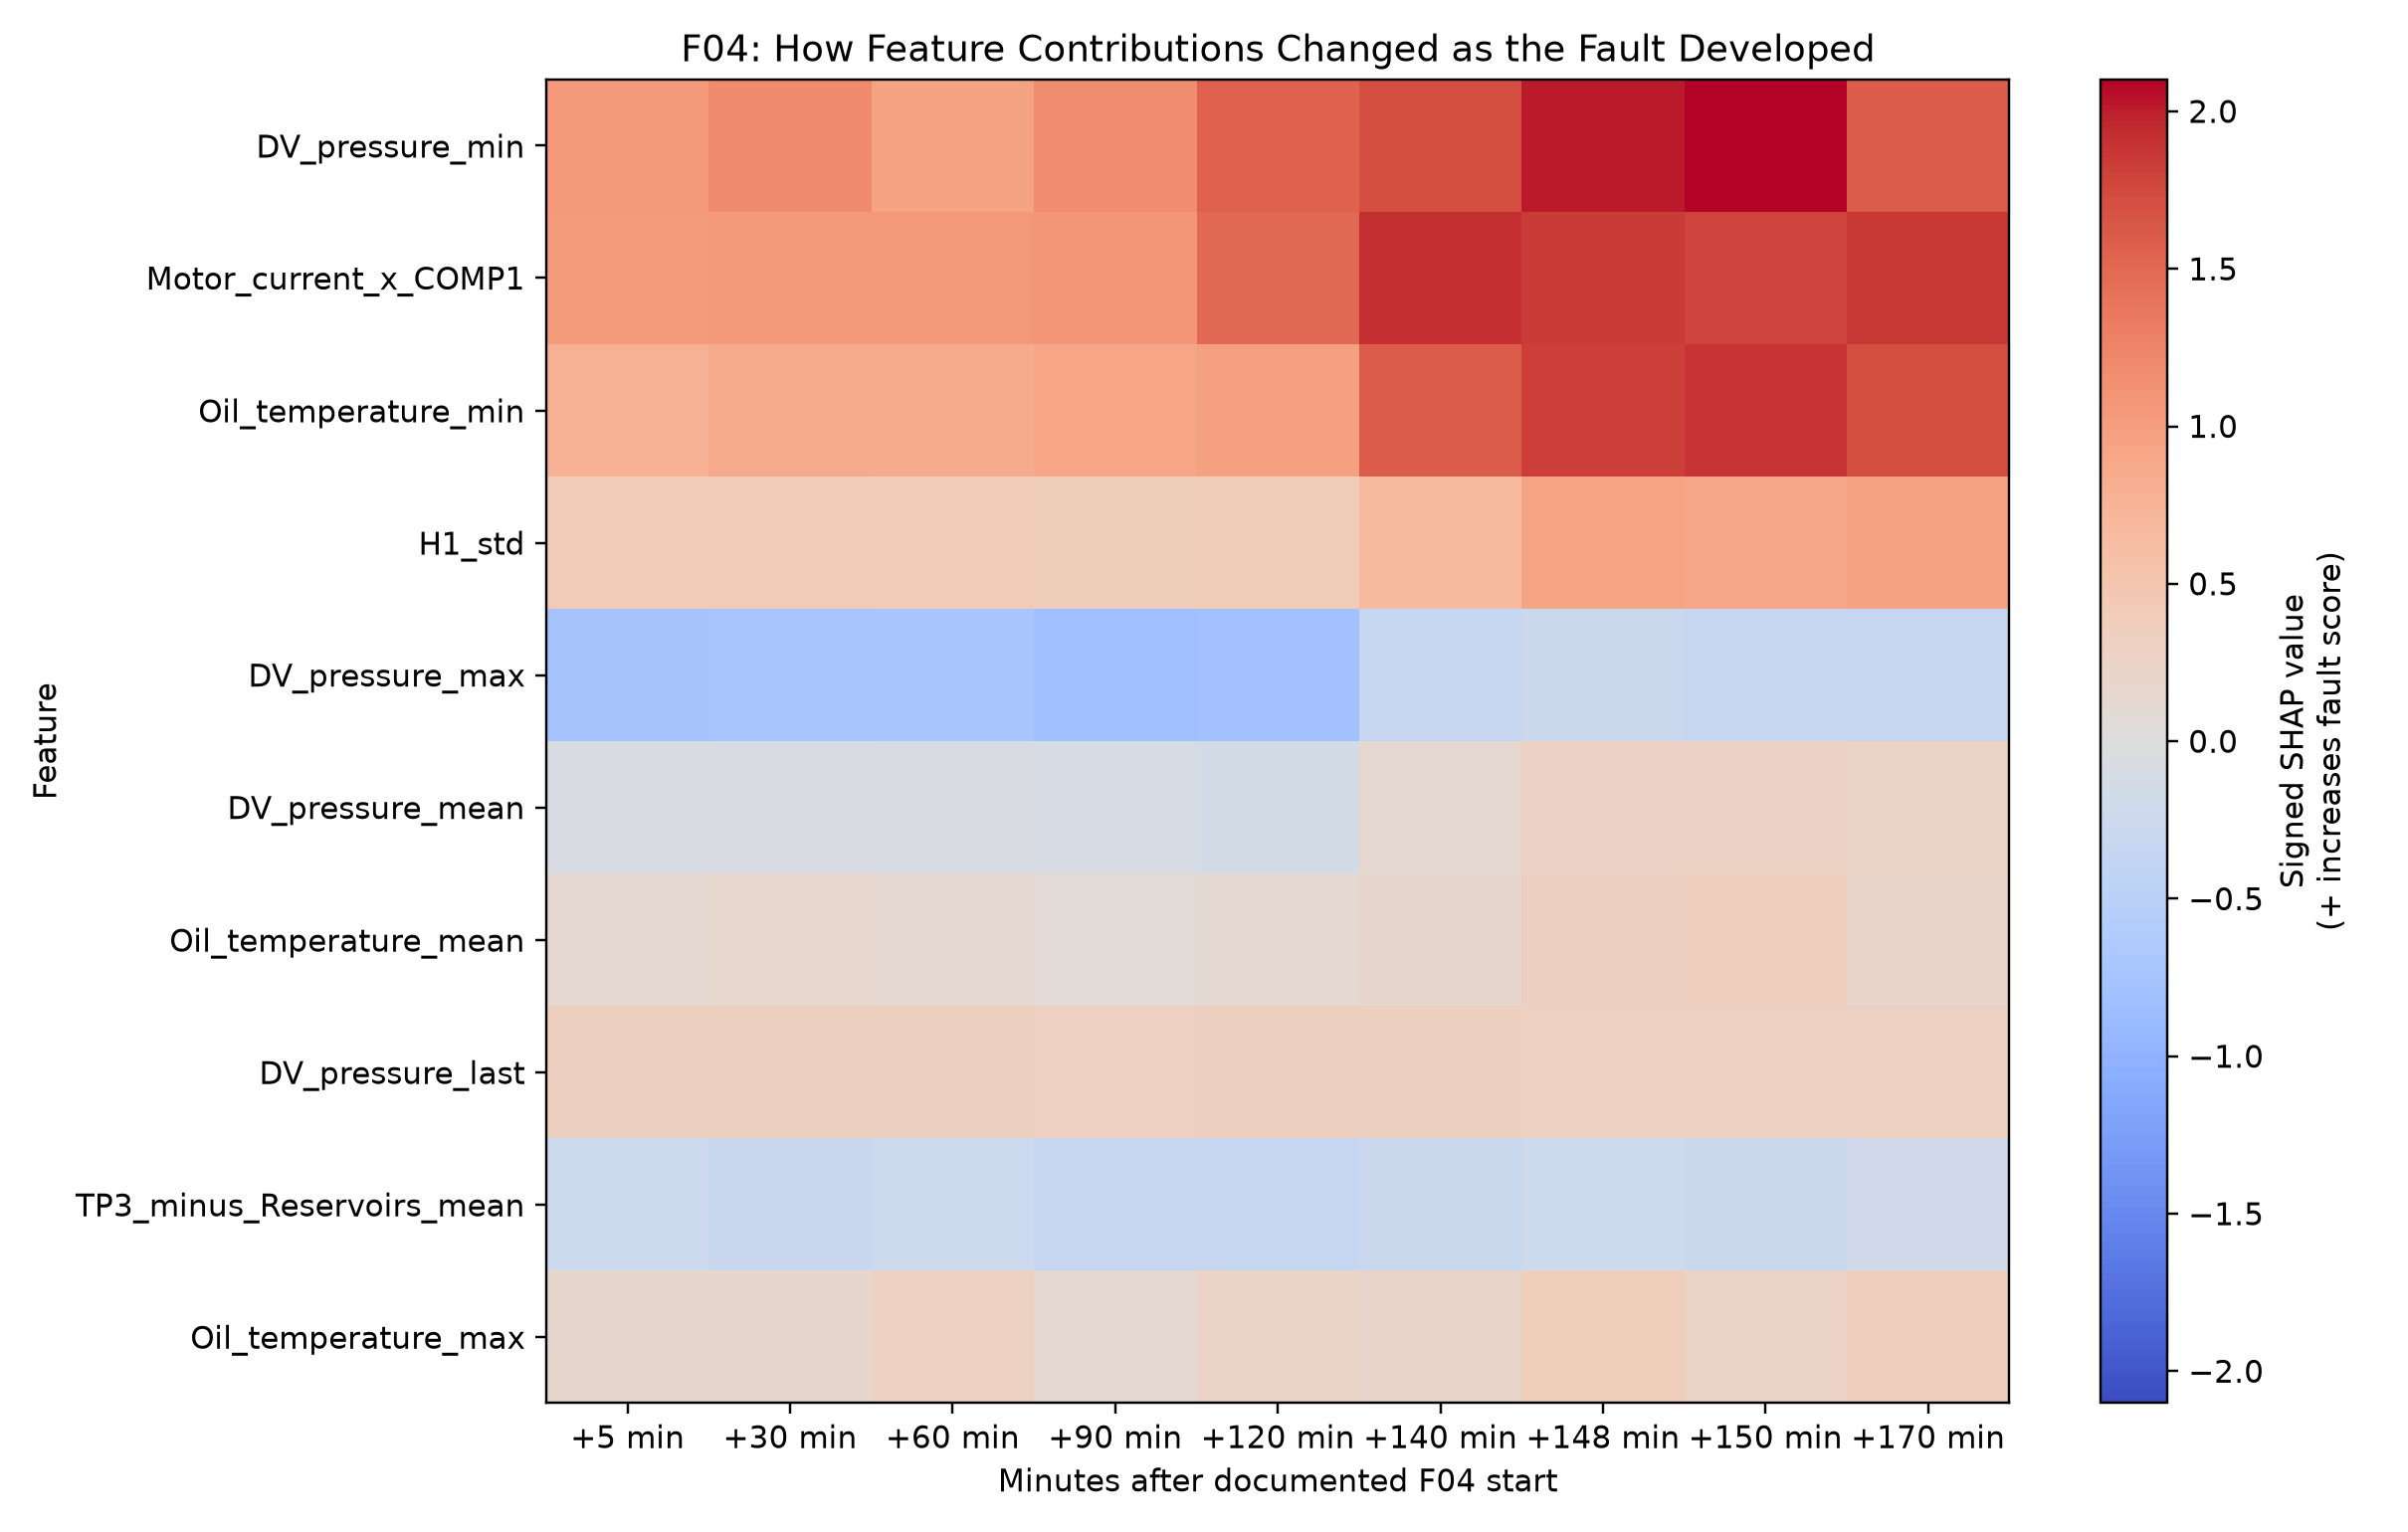

f04_top_feature_trajectories.png


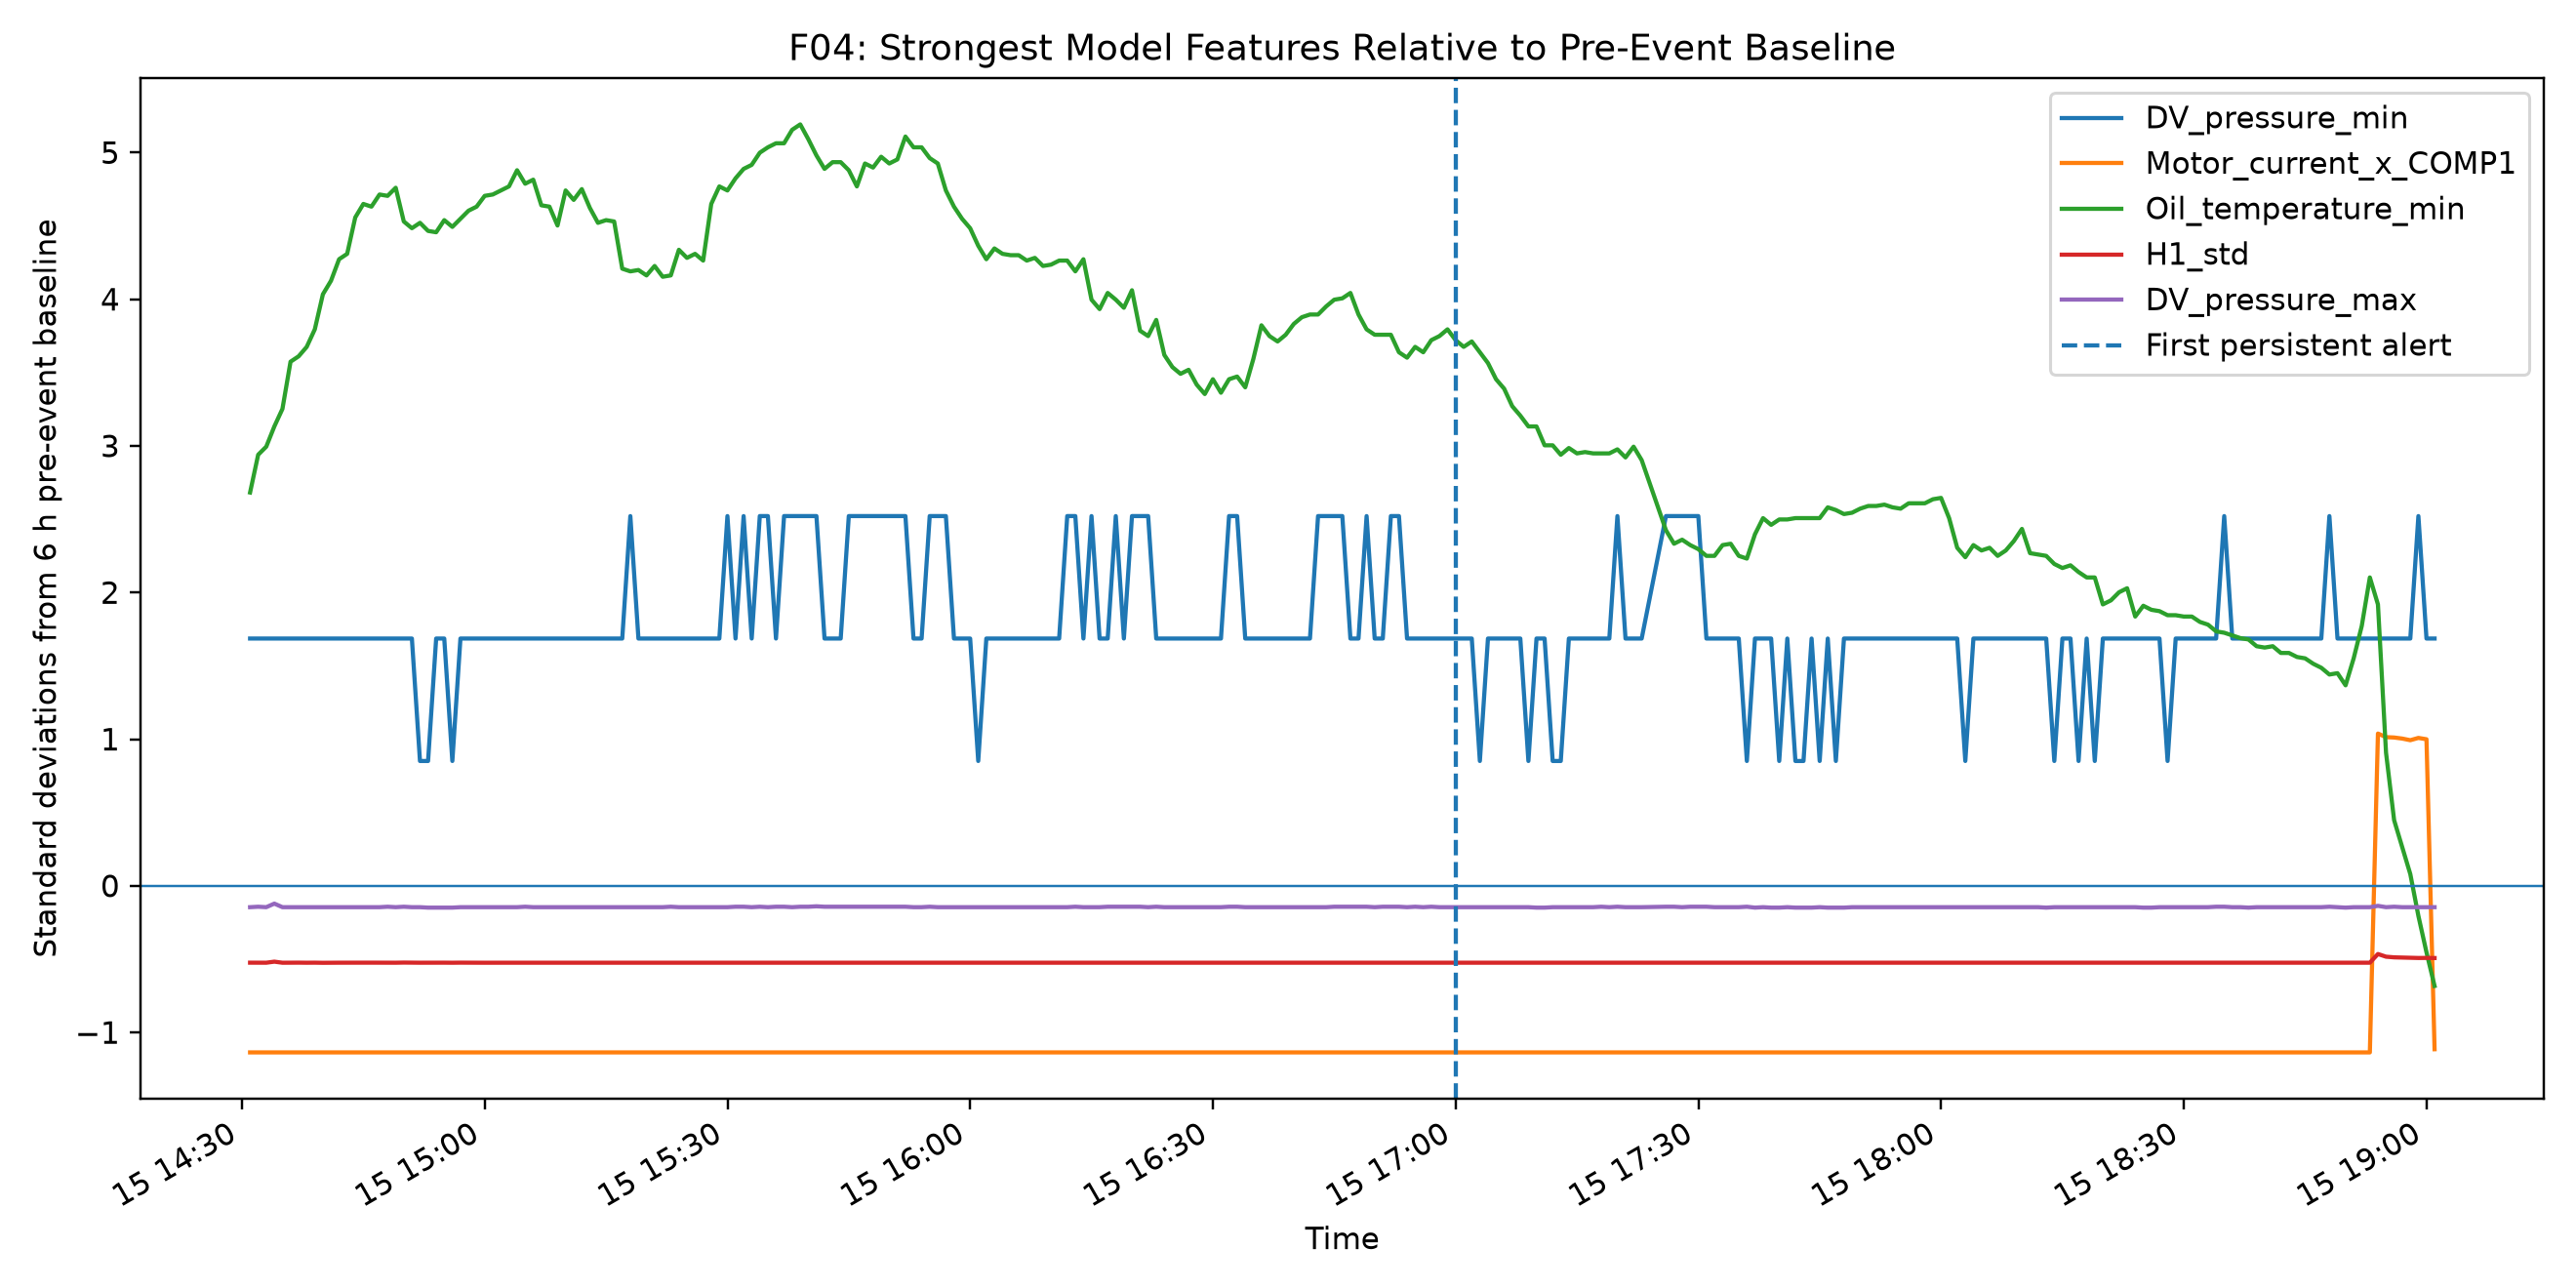

final_model_shap_holdout_bar.png


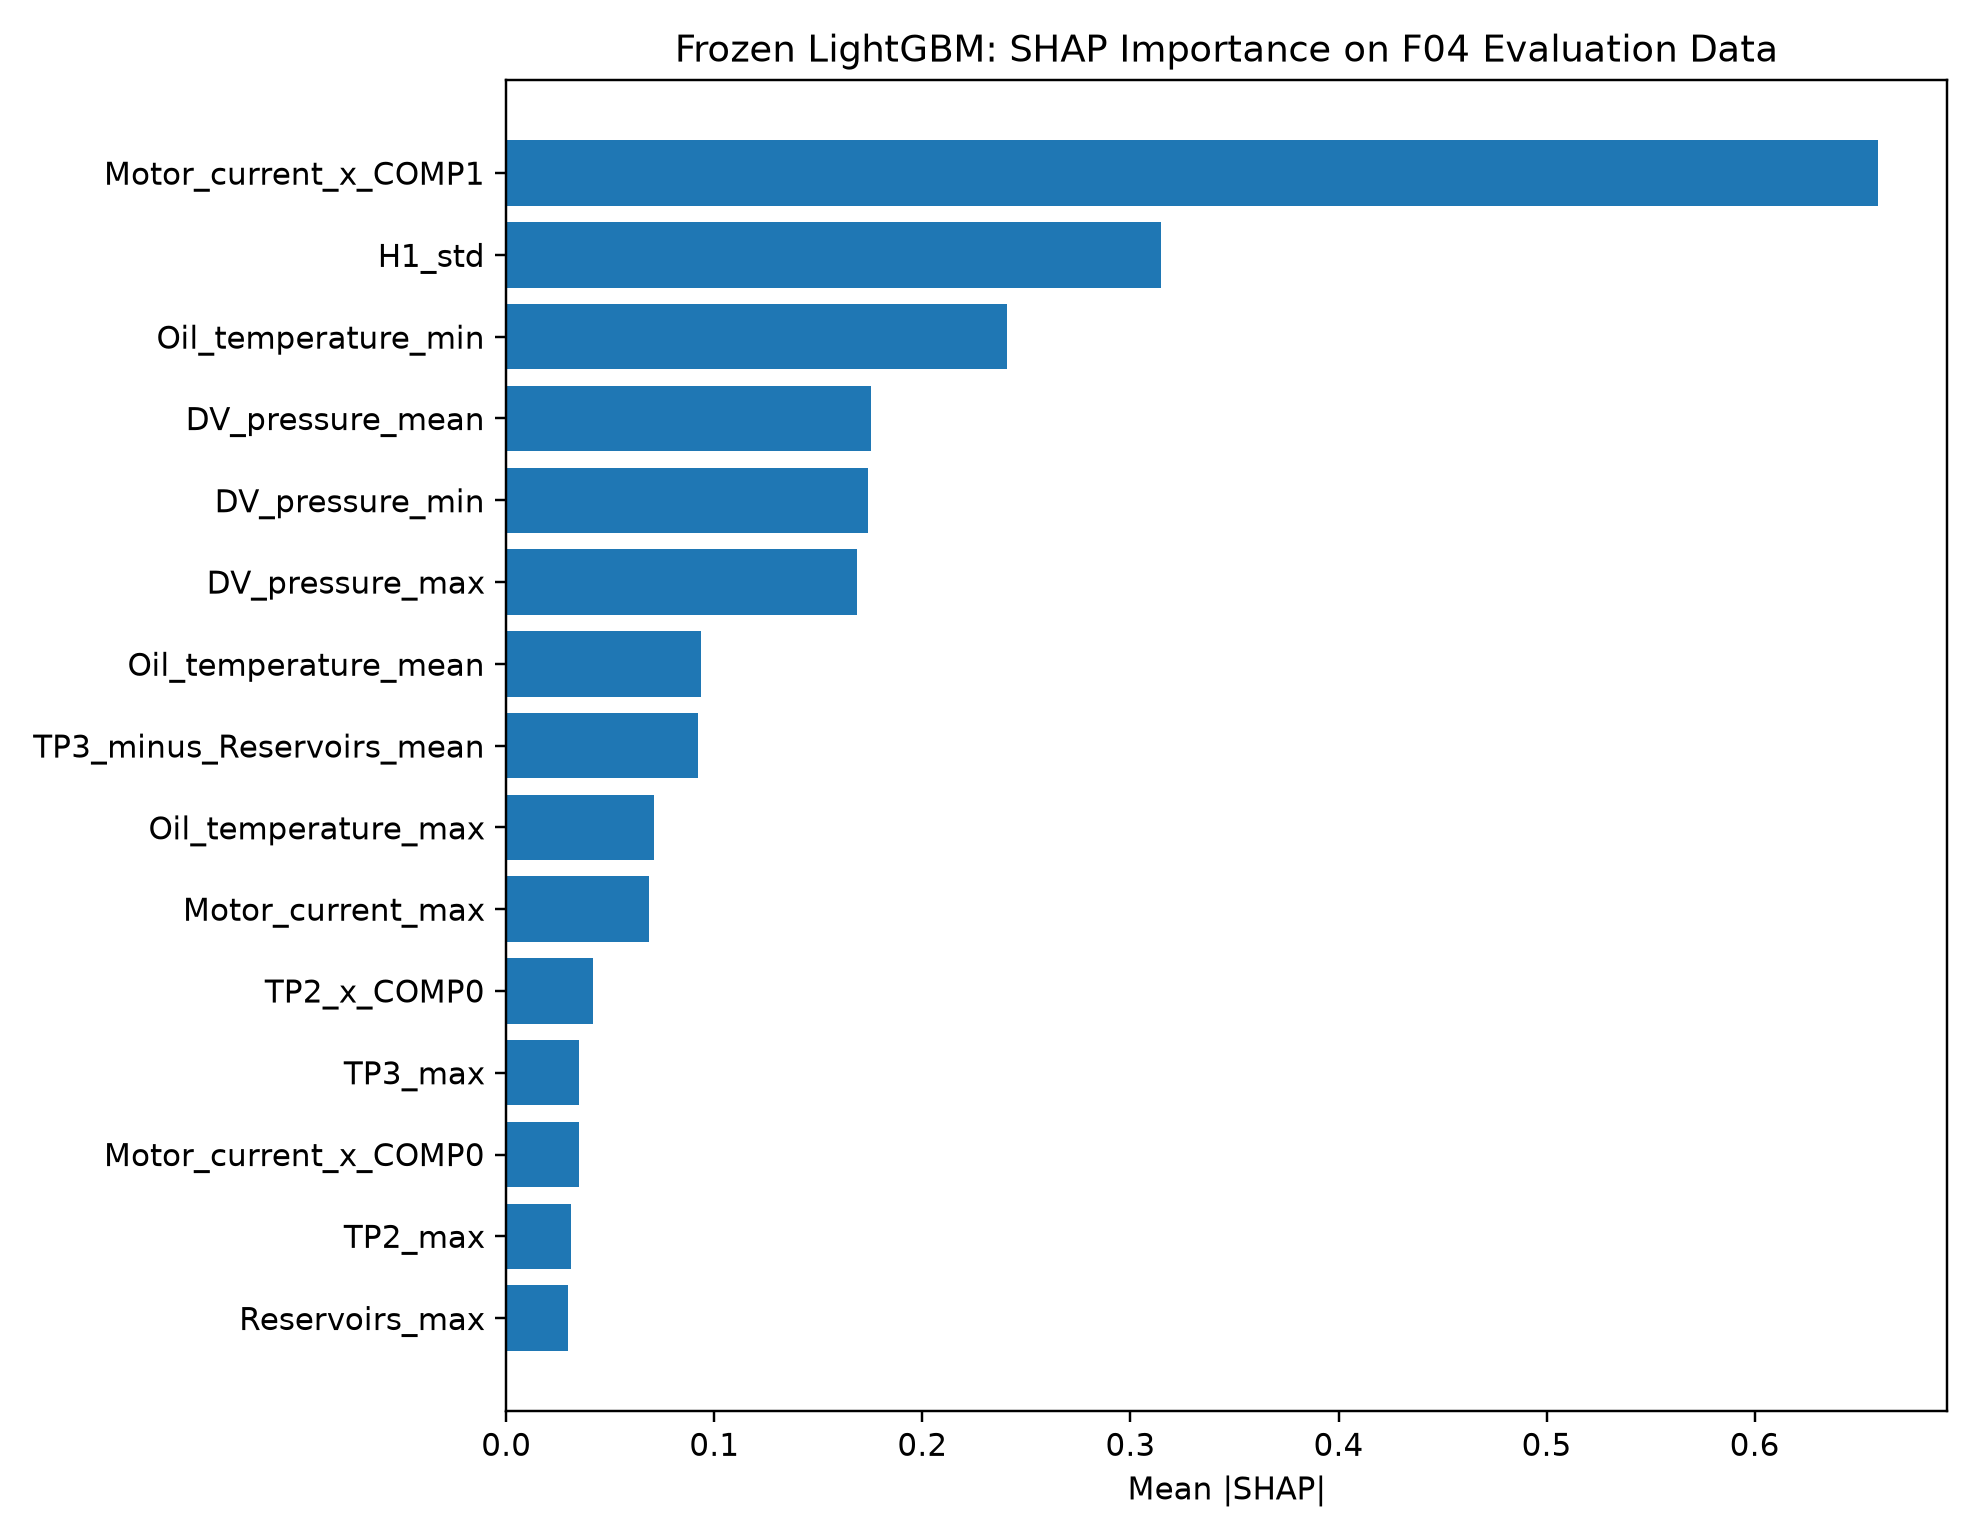

In [54]:
# Show saved SHAP figures if available.
from IPython.display import display, Image

figure_names = [
    "shap_event_comparison.png",
    "f04_risk_timeline.png",
    "f04_shap_checkpoint_heatmap.png",
    "f04_top_feature_trajectories.png",
    "final_model_shap_holdout_bar.png",
]

for name in figure_names:
    p = ROOT / "artifacts" / "figures" / name
    if p.exists():
        print(name)
        display(Image(filename=str(p)))

## 16. Ensemble & Deep-Learning Challengers

Additional models were evaluated after establishing the main LightGBM result to test whether greater model complexity could improve cross-event reliability.

In [55]:
ensemble_rank_path = ROOT / "artifacts" / "tables" / "ensemble_challenger_ranking_scoreboard.csv"
ensemble_op_path = ROOT / "artifacts" / "tables" / "ensemble_challenger_operational_scoreboard.csv"

if ensemble_rank_path.exists():
    ensemble_rank = pd.read_csv(ensemble_rank_path)
    display(ensemble_rank.sort_values("mean_pr_auc", ascending=False))

if ensemble_op_path.exists():
    ensemble_op = pd.read_csv(ensemble_op_path)
    display(
        ensemble_op.sort_values(
            ["events_detected", "worst_false_alarms_per_day"],
            ascending=[False, True],
        ).head(20)
    )

,candidate,mean_pr_auc,minimum_event_pr_auc,maximum_event_pr_auc,mean_average_precision,mean_roc_auc,mean_ap_lift
6,Random Forest Current,0.790726,0.605552,0.975899,0.598216,0.980969,13.352711
7,XGBoost Current,0.781020,0.572405,0.989636,0.575771,0.983994,10.005356
2,LGBM_XGB_50_50,0.780787,0.572426,0.989148,0.575555,0.983911,10.005632
4,LightGBM Current,0.779210,0.572504,0.985916,0.573973,0.983480,10.002174
5,MAX_LGBM_IF,0.772041,0.572449,0.971634,0.567065,0.981110,9.976244
3,LGBM_XGB_IF_40_40_20,0.527380,0.078931,0.975828,0.527662,0.969834,5.737269
1,LGBM_IF_80_20,0.525844,0.079739,0.971948,0.526135,0.969744,5.773330
0,Isolation Forest Current,0.354171,0.038922,0.669421,0.354403,0.903660,3.151562


,candidate,threshold_quantile,events_detected,median_detection_delay_minutes,mean_false_alarms_per_day,worst_false_alarms_per_day,events_total
18,LightGBM Current,0.9990,2,1.0,0.036216,0.072433,2
19,LightGBM Current,0.9995,2,1.0,0.036216,0.072433,2
22,MAX_LGBM_IF,0.9990,2,1.0,0.036216,0.072433,2
23,MAX_LGBM_IF,0.9995,2,1.0,0.036216,0.072433,2
9,LGBM_XGB_50_50,0.9950,2,1.0,0.376857,0.681281,2
17,LightGBM Current,0.9950,2,1.0,0.394965,0.681281,2
29,XGBoost Current,0.9950,2,1.0,0.376857,0.681281,2
25,Random Forest Current,0.9950,2,1.0,0.490403,0.908374,2
16,LightGBM Current,0.9900,2,1.0,0.880471,1.362561,2
4,LGBM_IF_80_20,0.9900,2,1.0,1.142299,1.376223,2


### Ensemble conclusion

Random Forest had strong ranking performance in the challenger experiment, while XGBoost and LightGBM produced partially correlated scores. However, no ensemble improved the **selected maintenance operating point** enough to justify extra complexity.

The `MAX_LGBM_IF` hybrid matched LightGBM's best operational result but had worse ranking performance and required an additional anomaly model. It was therefore rejected.

In [56]:
cnn_rank_path = ROOT / "artifacts" / "tables" / "tiny_cnn_ranking_scoreboard.csv"
cnn_op_path = ROOT / "artifacts" / "tables" / "tiny_cnn_operational_scoreboard.csv"

gru_rank_path = ROOT / "artifacts" / "tables" / "gru_30m_ranking_scoreboard.csv"
gru_op_path = ROOT / "artifacts" / "tables" / "gru_30m_operational_scoreboard.csv"

tables = {}

for label, p in [
    ("TinyCNN ranking", cnn_rank_path),
    ("TinyCNN operational", cnn_op_path),
    ("GRU ranking", gru_rank_path),
    ("GRU operational", gru_op_path),
]:
    if p.exists():
        tables[label] = pd.read_csv(p)
        print("\n", label)
        display(tables[label])


 TinyCNN ranking


,model,mean_pr_auc,minimum_event_pr_auc,maximum_event_pr_auc,mean_average_precision,mean_roc_auc,mean_ap_lift
0,TinyCNN-30m,0.634453,0.534222,0.734684,0.421045,0.857542,6.759256



 TinyCNN operational


,model,threshold_quantile,events_detected,median_detection_delay_minutes,mean_false_alarms_per_day,worst_false_alarms_per_day,events_total
0,TinyCNN-30m,0.9900,2,1.0,0.503614,0.681281,2
1,TinyCNN-30m,0.9950,2,1.0,0.240304,0.253515,2
2,TinyCNN-30m,0.9990,2,3.0,1.290580,2.354066,2
3,TinyCNN-30m,0.9995,2,3.0,0.584360,0.941626,2



 GRU ranking


,model,mean_pr_auc,minimum_event_pr_auc,maximum_event_pr_auc,mean_average_precision,mean_roc_auc,mean_ap_lift
0,GRU-30m,0.520758,0.088652,0.952864,0.520967,0.972831,6.191326



 GRU operational


,model,threshold_quantile,events_detected,median_detection_delay_minutes,mean_false_alarms_per_day,worst_false_alarms_per_day,events_total
0,GRU-30m,0.9900,2,2.5,0.693009,1.158925,2
1,GRU-30m,0.9950,2,3.0,0.693009,1.158925,2
2,GRU-30m,0.9990,2,4.5,0.788448,1.122708,2
3,GRU-30m,0.9995,2,6.0,0.674901,1.122708,2


### Deep-learning conclusion

**TinyCNN-30m**
- Mean PR-AUC: **0.634**
- Minimum-event PR-AUC: **0.534**
- detected both development events
- higher nuisance-alarm burden than LightGBM

**GRU-30m**
- Mean PR-AUC: **0.521**
- F02 PR-AUC: **0.089**
- F03 PR-AUC: **0.953**
- strong cross-event instability

The GRU result is particularly informative: it learned F03 extremely well but transferred poorly to F02. This demonstrates why millions of temporally correlated sensor rows cannot be treated as millions of independent fault examples.

## 17. Final Model-Selection Summary

In [57]:
model_summary = pd.DataFrame([
    {
        "model": "LightGBM Current",
        "mean_dev_PR_AUC": 0.920766,
        "min_event_PR_AUC": 0.855593,
        "events_detected": "2/2",
        "best_median_delay_min": 1.0,
        "selection": "SELECTED",
    },
    {
        "model": "TinyCNN-30m",
        "mean_dev_PR_AUC": 0.634453,
        "min_event_PR_AUC": 0.534222,
        "events_detected": "2/2",
        "best_median_delay_min": 1.0,
        "selection": "Rejected",
    },
    {
        "model": "GRU-30m",
        "mean_dev_PR_AUC": 0.520758,
        "min_event_PR_AUC": 0.088652,
        "events_detected": "2/2",
        "best_median_delay_min": 2.5,
        "selection": "Rejected",
    },
])

model_summary

,model,mean_dev_PR_AUC,min_event_PR_AUC,events_detected,best_median_delay_min,selection
0,LightGBM Current,0.920766,0.855593,2/2,1.0,SELECTED
1,TinyCNN-30m,0.634453,0.534222,2/2,1.0,Rejected
2,GRU-30m,0.520758,0.088652,2/2,2.5,Rejected


> **Model complexity was not treated as a proxy for intelligence.** The final model was selected because it provided the strongest chronological cross-event generalization, detection speed, nuisance-alarm control, explainability and deployment simplicity.

## 18. Proposed Industrial Deployment

AirGuard-LK is intended as a **human-in-the-loop maintenance decision-support layer**, not an autonomous shutdown system.

```text
Existing compressor sensors
          |
          v
PLC / industrial gateway
          |
          v
1-minute causal feature computation
          |
          v
State-aware LightGBM inference
          |
          v
3-minute persistent risk logic
          |
          +-------------------------+
          |                         |
          v                         v
Maintenance dashboard        SMS / mobile alert
          |
          v
Engineer inspection
```

### Example alert

**Risk:** HIGH  
**Evidence:** abnormal pressure/state + motor-current/temperature pattern  
**Action:** inspect compressor and pneumatic circuit for leak, valve or pressure instability.

### Sri Lankan deployment positioning

The deployment concept is relevant to apparel, food and beverage, packaging, plastics/rubber, tea processing, printing, metal fabrication, workshops and other facilities that rely on compressed air.

A real Sri Lankan pilot should integrate site-specific compressor sensors, maintenance logs and verified leak inspections before making performance or energy-saving claims.

## 19. Limitations & Future Work

### Main limitations

1. Only **four independent documented air-leak episodes** are available.
2. Sensor rows inside one event are highly correlated.
3. MetroPT-3 is international; no Sri Lankan field-validation claim is made.
4. Pre-event early-warning behaviour did not generalize consistently.
5. F04 required 150 minutes for persistent detection.
6. The primary eligibility protocol was conservative for the final current-feature model; this was analysed transparently post hoc.
7. SHAP explains model behaviour but does not prove physical causality.
8. Energy savings and LKR savings were not directly measured.

### Future work

A multi-site Sri Lankan pilot should collect:

- compressor / receiver pressure;
- motor current and electrical power;
- oil / discharge temperature;
- compressor duty state;
- valve and pneumatic status;
- maintenance work orders;
- verified leak inspection records.

A dataset containing many independent fault episodes would support stronger evaluation of GRU/LSTM/CNN architectures and genuine pre-fault prediction.

## 20. Reproducibility & AI-Assistance Disclosure

### Reproducibility controls

- random seed fixed at 42 where applicable;
- causal availability timestamps;
- acquisition-segment resets;
- no interpolation across long outages;
- event-wise chronological validation;
- training-normal-only threshold derivation;
- final configuration frozen before primary F04 evaluation;
- post-hoc analyses explicitly labelled;
- raw metrics stored as CSV/JSON/Parquet artifacts;
- scripts and configurations version-controlled in Git.

### AI assistance

AI tools were used to assist with code review, experiment planning, debugging, documentation and interpretation.

All experimental metrics and claims in this notebook are based on executed code and saved project artifacts. AI-generated placeholder values were not used as experimental results.

## 21. Reproducibility Artifact Manifest

In [58]:
artifact_files = [
    ROOT / "artifacts" / "metrics" / "final_F04_holdout_result.json",
    ROOT / "artifacts" / "metrics" / "final_F04_current_eligibility_sensitivity.json",
    ROOT / "artifacts" / "metrics" / "final_F04_predictions.parquet",
    ROOT / "artifacts" / "tables" / "final_F04_feature_importance.csv",
    ROOT / "artifacts" / "tables" / "final_F04_temporal_error_analysis.csv",
    ROOT / "artifacts" / "tables" / "shap_event_feature_importance.csv",
    ROOT / "artifacts" / "tables" / "f04_shap_checkpoints.csv",
    ROOT / "artifacts" / "tables" / "ensemble_challenger_ranking_scoreboard.csv",
    ROOT / "artifacts" / "tables" / "tiny_cnn_ranking_scoreboard.csv",
    ROOT / "artifacts" / "tables" / "gru_30m_ranking_scoreboard.csv",
    ROOT / "artifacts" / "models" / "airguard_F04_frozen_model.joblib",
]

manifest = pd.DataFrame([
    {
        "artifact": str(p.relative_to(ROOT)),
        "exists": p.exists(),
        "size_MB": round(p.stat().st_size / (1024**2), 3) if p.exists() else np.nan,
    }
    for p in artifact_files
])

manifest

,artifact,exists,size_MB
0,artifacts\metrics\final_F04_holdout_result.json,True,0.001
1,artifacts\metrics\final_F04_current_eligibilit...,True,0.001
2,artifacts\metrics\final_F04_predictions.parquet,True,34.994
3,artifacts\tables\final_F04_feature_importance.csv,True,0.002
4,artifacts\tables\final_F04_temporal_error_anal...,True,0.001
5,artifacts\tables\shap_event_feature_importance...,True,0.015
6,artifacts\tables\f04_shap_checkpoints.csv,True,0.009
7,artifacts\tables\ensemble_challenger_ranking_s...,True,0.001
8,artifacts\tables\tiny_cnn_ranking_scoreboard.csv,True,0.000
9,artifacts\tables\gru_30m_ranking_scoreboard.csv,True,0.000


## 22. Conclusion

AirGuard-LK demonstrates that compressed-air predictive maintenance should be evaluated at the **fault-event level**, not simply through randomly split sensor rows.

The original pre-fault prediction hypothesis was tested and found to be inconsistent across independent events. After reformulating the task, a state-aware LightGBM model provided the strongest development performance and substantially lower nuisance-alarm burden than simple static thresholds and the more complex ensemble/deep-learning challengers.

The frozen model detected the difficult F04 chronological holdout with zero false-alarm episodes, although only after 150 minutes. Post-hoc eligibility sensitivity improved F04 ranking coverage but did not change the detection latency, confirming that the late alert reflects genuine event/model behaviour rather than only a missing-data artifact.

SHAP analysis showed that pressure-related behaviour was repeatedly informative across F02–F04, while the exact pressure, state, current and temperature evidence varied between events.

The contribution is therefore not a claim of perfect prediction. It is a **leakage-aware, explainable, event-level and operationally evaluated industrial AI workflow** that can be extended to future Sri Lankan compressed-air monitoring pilots.

## 23. References

1. **MetroPT-3 Dataset**, UCI Machine Learning Repository. DOI: **10.24432/C5VW3R**.
2. Davari, N.; Veloso, B.; Ribeiro, R.; Gama, J. — MetroPT-3 dataset creators / associated predictive-maintenance work.
3. Ke, G. et al. — *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*.
4. Lundberg, S. M.; Lee, S.-I. — *A Unified Approach to Interpreting Model Predictions* (SHAP).
5. Final competition report should include the exact MetroPT-3 dataset citation/version and any additional compressed-air / industrial predictive-maintenance sources used in the written literature review.